# Mumford and Shah Model
Minimizes the energy functional wrt $u$ and $C$:
$$E^{MS}(u,C)=\int_{\Omega}(I-u)^{2}dx+\mu\int_{\Omega\backslash C}|\nabla u|^{2}dx+v|C|$$

Where $u$ is the approximated image and $C$ is the approximated edges.

**Data Fidelity** ($\int_{\Omega}(I-u)^{2}dx$): This penalizes the squared difference between the original image $I$ and the approximated image $u$. It forces the segmented approximation to stay faithful to the ground truth. 

**Smoothness Penalty** ($\mu\int_{\Omega\backslash C}|\nabla u|^{2}dx$): This penalizes large gradients in $u$ everywhere except at the boundaries ($C$). Controlled by the parameter $\mu$, it forces the regions inside the boundaries to be relatively uniform and smooth, clearing out noise.

**Contour Penalty** ($v|C|$): This penalizes the total geometric length of the boundary curves $C$, controlled by the weight $v$. This acts as a regularization term to prevent over-segmentation, encouraging shorter, smoother boundaries rather than jagged, highly complex edges.

Difficult to minimize the above functional in practice, due to the unknown set $C$ of lower dimension and the non-convexity of the functional.

# C-V Model

Approximates the intensities inside the contour $C$ with a single constant $c_1$, and the outside with another constant $c_2$. This drastically simplifies the energy functional:
$$E^{CV}(c_{1},c_{2},C)=\int_{inside(C)}(I-c_{1})^{2}dx+\int_{outside(C)}(I-c_{2})^{2}dx+v|C|$$

Instead of trying to approximate the image with a complex, continuously varying function, the C-V model assumes the image essentially consists of just two homogeneous regions: the foreground and the background.

The C-V model performs well on homogeneous image, since that $c_1$ and $c_2$ are two constants to approximate the average intensities inside and outside the contour $C$. However, if the image becomes complicated, merely using intensity information might be inadequate to segment the image.

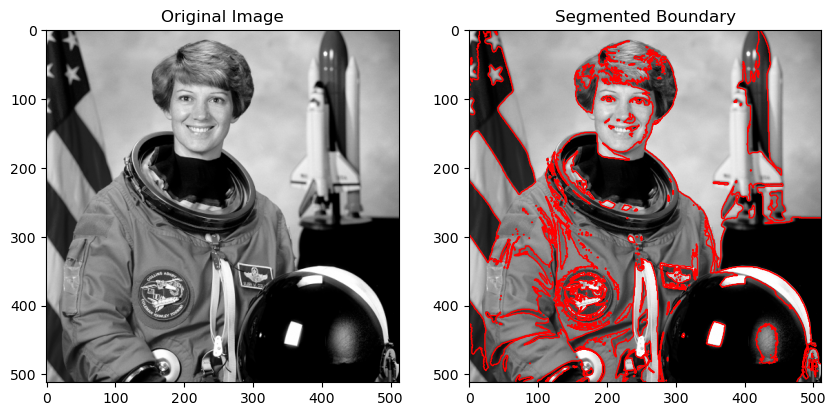

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

def simple_chan_vese(image, iterations=200, dt=1.0, mu=0.5, lambda1=100.0, lambda2=100.0):
    rows, cols = image.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # 1. Initialize phi and normalize the state variable magnitude
    phi = np.sqrt((X - cols/2)**2 + (Y - rows/2)**2) - min(rows, cols)/3
    phi = phi / np.max(np.abs(phi)) 
    
    for _ in range(iterations):
        inside = phi <= 0
        outside = phi > 0
        
        c1 = np.mean(image[inside]) if np.any(inside) else 0
        c2 = np.mean(image[outside]) if np.any(outside) else 0
        
        # 2. Calculate data force with dynamic multipliers
        data_force = lambda2 * (image - c2)**2 - lambda1 * (image - c1)**2
        
        # Calculate the curvature (smoothness penalty)
        dy, dx = np.gradient(phi)
        gradient_norm = np.sqrt(dx**2 + dy**2) + 1e-8
        
        nxx, _ = np.gradient(dx / gradient_norm)
        _, nyy = np.gradient(dy / gradient_norm)
        curvature = nxx + nyy
        
        # 3. Approximate the Dirac Delta function to localize the update
        epsilon = 1.0
        dirac_phi = epsilon / (np.pi * (epsilon**2 + phi**2))
        
        # Update phi using the fully scaled gradient descent flow
        phi = phi + dt * dirac_phi * (data_force + mu * curvature)
        
    return phi <= 0

img = color.rgb2gray(data.astronaut())
img = (img - np.min(img)) / (np.max(img) - np.min(img))

# With the scaled forces, the contour will rapidly snap to the subject
mask = simple_chan_vese(img, iterations=1, dt=1.0, mu=0.2, lambda1=150.0, lambda2=150.0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(img, cmap='gray')
ax[1].contour(mask, [0.5], colors='red', linewidths=1)
ax[1].set_title("Segmented Boundary")

plt.show()